# 📊 Data Storytelling — Customer Lifecycle Analysis

---

> **Q1 — Acquisition & First Purchase:** *"Khách hàng đến từ đâu? Kênh nào mang lại nhiều khách nhất và ai có giá trị cao nhất ngay từ lần mua đầu?"*

> **Q2 — Retention, CLV & Churn:** *"Sau lần mua đầu, bao nhiêu % khách hàng quay lại? Phân khúc nào có Lifetime Value cao nhất và ai đang có nguy cơ rời bỏ?"*

---

**Dataset:** E-commerce thời trang Việt Nam | **2012–2022** | 121K khách hàng · 647K đơn hàng · 10 năm

---

### Vòng Đời Khách Hàng

```
[Mua lần đầu] ──▶ [Quay lại lần 2] ──▶ [Trở thành Loyal] ──▶ [Churn]
      Q1                  Q1                    Q2                 Q2
```

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': '#0f1117',
    'axes.facecolor':   '#1a1d27',
    'axes.edgecolor':   '#2e3347',
    'axes.labelcolor':  '#c9d1e0',
    'axes.titlecolor':  '#ffffff',
    'xtick.color':      '#8892a4',
    'ytick.color':      '#8892a4',
    'grid.color':       '#2e3347',
    'grid.linewidth':   0.6,
    'text.color':       '#c9d1e0',
    'font.family':      'DejaVu Sans',
    'font.size':        11,
    'axes.titlesize':   14,
    'axes.titleweight': 'bold',
    'legend.facecolor': '#1a1d27',
    'legend.edgecolor': '#2e3347',
})

PALETTE  = ['#4e9ff5','#f5a623','#50e3c2','#e87070','#b97ef9','#f5d442','#ff8c69','#a8e6cf']
SEG_COLORS = {
    'Champions':      '#50e3c2',
    'Loyal':          '#4e9ff5',
    'Promising':      '#f5d442',
    'At Risk':        '#f5a623',
    'Lost':           '#e87070',
    'New':            '#b97ef9',
    'Hibernating':    '#8892a4',
}
print("Libraries loaded ✓")

Libraries loaded ✓


In [2]:
customers = pd.read_csv('../data/raw/customers.csv', low_memory=False)
orders    = pd.read_csv('../data/raw/orders.csv', parse_dates=['order_date'])
payments  = pd.read_csv('../data/raw/payments.csv')

# Chỉ lấy đơn hàng hoàn thành (loại cancelled)
VALID_STATUS = {'delivered', 'shipped', 'paid', 'returned'}
orders_valid = orders[orders['order_status'].isin(VALID_STATUS)].copy()

# Doanh thu mỗi đơn từ payments
order_revenue = (payments.groupby('order_id')['payment_value']
                 .sum().reset_index(name='revenue'))
orders_valid = orders_valid.merge(order_revenue, on='order_id', how='left')
orders_valid['year']  = orders_valid['order_date'].dt.year
orders_valid['month'] = orders_valid['order_date'].dt.to_period('M')

# ── Tổng hợp theo khách hàng ──────────────────────────────────────────────
cust_stats = (orders_valid
              .groupby('customer_id')
              .agg(
                  first_order_date = ('order_date', 'min'),
                  last_order_date  = ('order_date', 'max'),
                  total_orders     = ('order_id',   'count'),
                  total_revenue    = ('revenue',    'sum'),
              )
              .reset_index())

cust_stats = cust_stats.merge(
    customers[['customer_id', 'gender', 'age_group', 'acquisition_channel']],
    on='customer_id', how='left')

cust_stats['customer_lifespan_days'] = (
    cust_stats['last_order_date'] - cust_stats['first_order_date']).dt.days

SNAPSHOT = pd.Timestamp('2022-12-31')
cust_stats['recency_days'] = (SNAPSHOT - cust_stats['last_order_date']).dt.days

print(f"Khách hàng có ít nhất 1 đơn hàng hợp lệ : {len(cust_stats):,}")
print(f"Tổng khách hàng trong dataset              : {len(customers):,}")
print(f"Khách chưa có đơn nào                      : {len(customers) - len(cust_stats):,}")
print()
print(cust_stats[['total_orders','total_revenue','recency_days']].describe().round(1))

Khách hàng có ít nhất 1 đơn hàng hợp lệ : 87,839
Tổng khách hàng trong dataset              : 121,930
Khách chưa có đơn nào                      : 34,091

       total_orders  total_revenue  recency_days
count       87839.0        87839.0       87839.0
mean            6.6       159974.7        1288.5
std             7.8       198688.5        1029.7
min             1.0          445.6           0.0
25%             1.0        29910.3         336.0
50%             4.0        84681.6        1032.0
75%             9.0       216058.7        2022.0
max           100.0      3336864.8        3832.0


---

# 1. Acquisition & First Purchase

> *"Khách hàng đến từ đâu? Kênh nào mang lại nhiều khách nhất, ai mua nhiều và quay lại nhanh nhất?"*

**4 góc nhìn:**
1. Số khách hàng mới theo năm & kênh acquisition
2. Demographics: giới tính và nhóm tuổi
3. Thời gian từ lần mua đầu → lần mua thứ hai
4. Giá trị đơn đầu tiên & CLV theo kênh

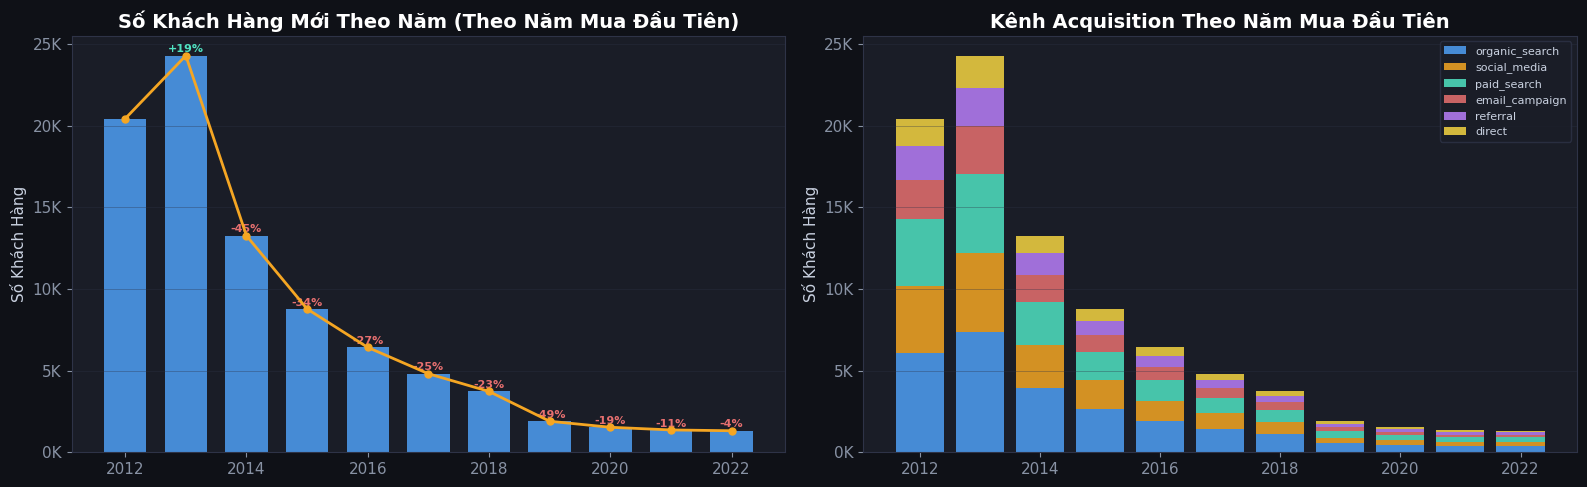

Tỷ trọng kênh acquisition (toàn giai đoạn):
acquisition_channel
organic_search    29.9
social_media      19.9
paid_search       19.9
email_campaign    12.0
referral          10.1
direct             8.1

Peak: 2013 với 24,290 khách mới


In [3]:
## 1.1 Khách Hàng Mới Theo Năm & Kênh Acquisition
# first_order_year = năm thực sự bắt đầu mua, đáng tin hơn signup_date (89% bị lỗi migration)
first_order_year = (orders_valid.groupby('customer_id')['order_date']
                    .min().dt.year.reset_index(name='first_order_year'))
cust_acq = customers.merge(first_order_year, on='customer_id', how='left')
cust_acq = cust_acq.dropna(subset=['first_order_year'])
cust_acq['first_order_year'] = cust_acq['first_order_year'].astype(int)

new_by_year = cust_acq.groupby('first_order_year').size().reset_index(name='new_customers')
new_by_channel = (cust_acq.groupby(['first_order_year','acquisition_channel'])
                  .size().reset_index(name='count'))
pivot_ch = new_by_channel.pivot(index='first_order_year', columns='acquisition_channel', values='count').fillna(0)

ch_order = cust_acq['acquisition_channel'].value_counts().index.tolist()
ch_colors = dict(zip(ch_order, PALETTE))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor('#0f1117')

# ── Left: total new customers per year ──────────────────────────────────
ax = axes[0]
bars = ax.bar(new_by_year['first_order_year'], new_by_year['new_customers'],
              color='#4e9ff5', alpha=0.85, width=0.7)
ax.plot(new_by_year['first_order_year'], new_by_year['new_customers'],
        color='#f5a623', linewidth=2, marker='o', markersize=5, zorder=5)
yoy = new_by_year['new_customers'].pct_change() * 100
for i, (_, row) in enumerate(new_by_year.iterrows()):
    if i > 0 and not np.isnan(yoy.iloc[i]):
        color = '#50e3c2' if yoy.iloc[i] > 0 else '#e87070'
        ax.text(row['first_order_year'], row['new_customers'] + 200,
                f"{yoy.iloc[i]:+.0f}%", ha='center', fontsize=8,
                color=color, fontweight='bold')
ax.set_title('Số Khách Hàng Mới Theo Năm (Theo Năm Mua Đầu Tiên)')
ax.set_ylabel('Số Khách Hàng')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{v/1000:.0f}K'))
ax.grid(axis='y', alpha=0.4)

# ── Right: stacked bar by acquisition channel ────────────────────────────
ax2 = axes[1]
bottom = np.zeros(len(pivot_ch))
for ch in ch_order:
    if ch in pivot_ch.columns:
        vals = pivot_ch[ch].values
        ax2.bar(pivot_ch.index, vals, bottom=bottom,
                label=ch, color=ch_colors[ch], alpha=0.85)
        bottom += vals
ax2.set_title('Kênh Acquisition Theo Năm Mua Đầu Tiên')
ax2.set_ylabel('Số Khách Hàng')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{v/1000:.0f}K'))
ax2.legend(fontsize=8, loc='upper right')
ax2.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig('../outputs/charts/lifecycle/lc_01_acquisition.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

ch_share = cust_acq['acquisition_channel'].value_counts(normalize=True).mul(100).round(1)
print("Tỷ trọng kênh acquisition (toàn giai đoạn):")
print(ch_share.to_string())
peak = new_by_year.loc[new_by_year.new_customers.idxmax()]
print(f"\nPeak: {peak['first_order_year']} với {peak['new_customers']:,} khách mới")

**Insight 1.1:**
- Acquisition đạt đỉnh **2013 (24,290 khách)** rồi giảm liên tục không hồi phục — đây là vấn đề tăng trưởng cốt lõi, không phải chỉ là retention.
- Mix kênh **không thay đổi suốt 10 năm** → không có thử nghiệm kênh nào mới, organic search vẫn chiếm 30% mà không được scale.

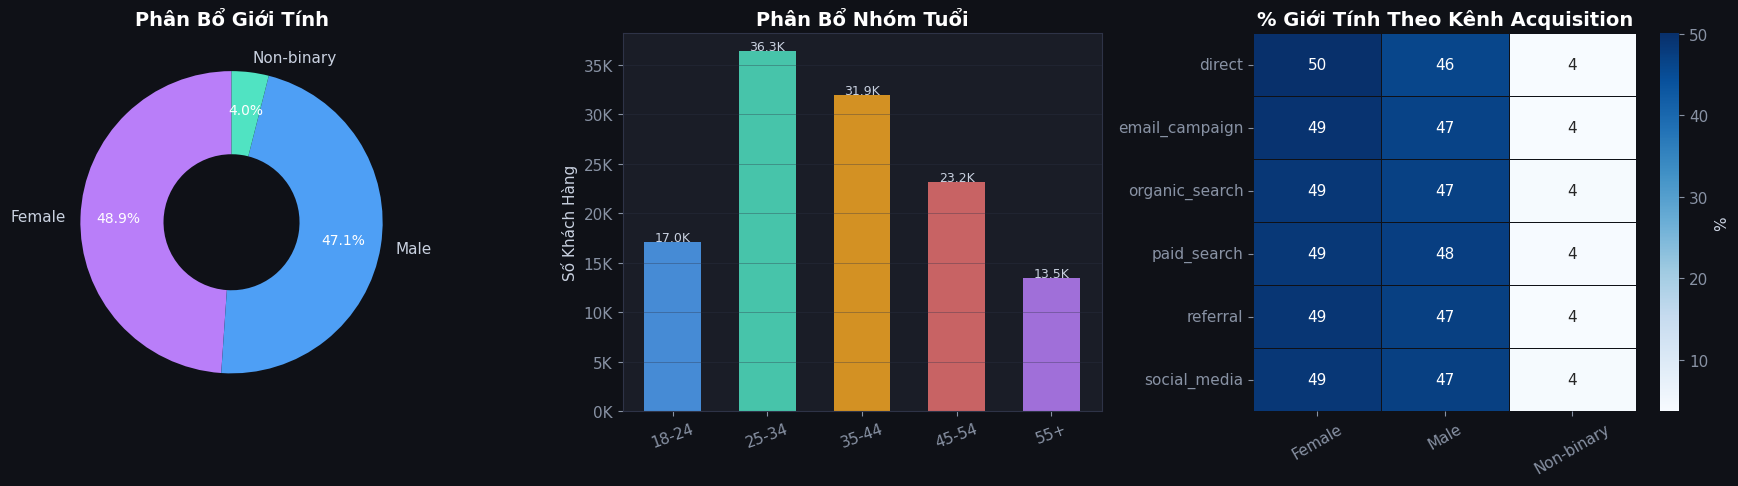

In [4]:
## 1.2 Demographics: Ai Đang Mua Hàng?

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor('#0f1117')

# ── Left: gender distribution ────────────────────────────────────────────
ax = axes[0]
gender_counts = customers['gender'].value_counts()
wedges, texts, autos = ax.pie(
    gender_counts,
    labels=gender_counts.index,
    colors=['#b97ef9','#4e9ff5','#50e3c2'],
    autopct='%1.1f%%', startangle=90,
    wedgeprops=dict(width=0.55), pctdistance=0.75
)
for a in autos: a.set_color('#fff'); a.set_fontsize(10)
ax.set_title('Phân Bổ Giới Tính')

# ── Middle: age group bar ────────────────────────────────────────────────
ax2 = axes[1]
age_counts = customers['age_group'].value_counts().sort_index()
age_colors = ['#4e9ff5','#50e3c2','#f5a623','#e87070','#b97ef9','#f5d442']
bars = ax2.bar(age_counts.index, age_counts.values,
               color=age_colors[:len(age_counts)], alpha=0.85, width=0.6)
for bar, val in zip(bars, age_counts.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
             f'{val/1000:.1f}K', ha='center', fontsize=9, color='#c9d1e0')
ax2.set_title('Phân Bổ Nhóm Tuổi')
ax2.set_ylabel('Số Khách Hàng')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{v/1000:.0f}K'))
ax2.grid(axis='y', alpha=0.4)
ax2.tick_params(axis='x', rotation=20)

# ── Right: channel × gender heatmap ─────────────────────────────────────
ax3 = axes[2]
ch_gender = (customers.groupby(['acquisition_channel','gender'])
             .size().unstack(fill_value=0))
ch_gender_pct = ch_gender.div(ch_gender.sum(axis=1), axis=0) * 100
sns.heatmap(ch_gender_pct, annot=True, fmt='.0f', cmap='Blues',
            ax=ax3, cbar_kws={'label':'%'},
            linewidths=0.5, linecolor='#0f1117')
ax3.set_title('% Giới Tính Theo Kênh Acquisition')
ax3.set_xlabel('')
ax3.set_ylabel('')
ax3.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('../outputs/charts/lifecycle/lc_02_demographics.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

**Insight 1.2:**
- Giới tính gần cân bằng (49F/47M) và **đồng đều trên mọi kênh** → không thể dùng kênh để nhắm mục tiêu giới tính, cần personalise ở tầng nội dung.
- Core audience là **25–34 tuổi (30%) và 35–44 tuổi (26%)** — người đi làm có thu nhập, không phải Gen Z. Product mix và giá cần phản ánh điều này.

Khách có >= 2 đơn hàng (có T2P): 65,123 (74.1%)
count    65123.0
mean       532.1
std        611.6
min          0.0
25%        103.0
50%        308.0
75%        732.0
max       3785.0


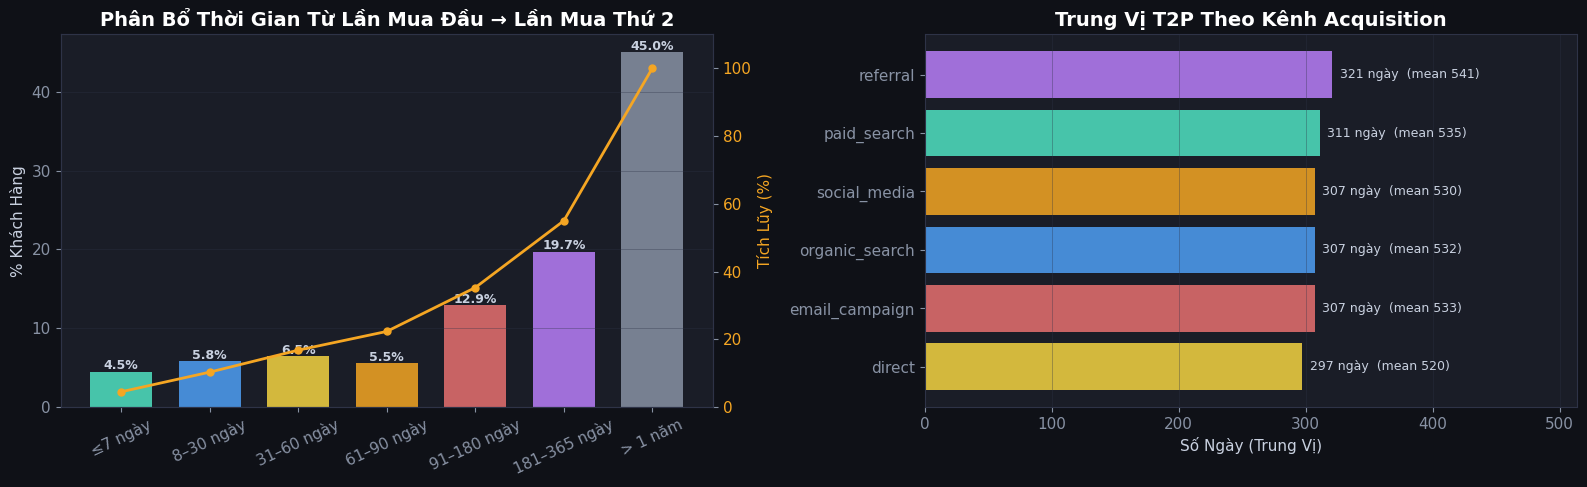


Trung vị T2P: 308 ngày (~10.3 tháng)
Tỷ lệ quay lại trong 30 ngày đầu: 10.3%
Tỷ lệ quay lại sau hơn 1 năm:     45.0%

Phân tích trên 65,123 khách có ít nhất 2 đơn hàng (74.1% tổng dataset)


In [5]:
## 1.3 Time-to-2nd-Purchase (T2P): Sau Lần Mua Đầu, Khách Mất Bao Lâu Để Quay Lại?
# signup_date không đáng tin (89% bị lỗi migration) → dùng khoảng cách đơn 1→2 thay thế

o = orders_valid.sort_values(['customer_id','order_date']).copy()
o['rank']      = o.groupby('customer_id').cumcount() + 1
o['prev_date'] = o.groupby('customer_id')['order_date'].shift(1)

o2 = o[o['rank'] == 2].copy()
o2['t2p_days'] = (o2['order_date'] - o2['prev_date']).dt.days
o2 = o2.dropna(subset=['t2p_days'])

n_repeat = len(o2)
n_total  = cust_stats['customer_id'].nunique()
print(f"Khách có >= 2 đơn hàng (có T2P): {n_repeat:,} ({n_repeat/n_total*100:.1f}%)")
print(o2['t2p_days'].describe().round(1).to_string())

bins   = [0, 7, 30, 60, 90, 180, 365, 9999]
labels = ['≤7 ngày','8–30 ngày','31–60 ngày','61–90 ngày','91–180 ngày','181–365 ngày','> 1 năm']
o2['t2p_group'] = pd.cut(o2['t2p_days'], bins=bins, labels=labels, right=True)

t2p_counts = o2['t2p_group'].value_counts().reindex(labels)
t2p_pct    = t2p_counts / t2p_counts.sum() * 100

# Median T2P per acquisition channel
o2_ch = o2.merge(customers[['customer_id','acquisition_channel']], on='customer_id', how='left')
t2p_ch = (o2_ch.groupby('acquisition_channel')['t2p_days']
          .agg(['median','mean'])
          .sort_values('median')
          .reset_index())

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor('#0f1117')

# ── Left: T2P distribution ───────────────────────────────────────────────
ax = axes[0]
colors_t2p = ['#50e3c2','#4e9ff5','#f5d442','#f5a623','#e87070','#b97ef9','#8892a4']
bars = ax.bar(t2p_counts.index, t2p_pct, color=colors_t2p, alpha=0.85, width=0.7)
for bar, pct in zip(bars, t2p_pct):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            f'{pct:.1f}%', ha='center', fontsize=9,
            color='#c9d1e0', fontweight='bold')
ax.set_title('Phân Bổ Thời Gian Từ Lần Mua Đầu → Lần Mua Thứ 2')
ax.set_ylabel('% Khách Hàng')
ax.tick_params(axis='x', rotation=25)
ax.grid(axis='y', alpha=0.4)
ax_r = ax.twinx()
cum = t2p_pct.cumsum()
ax_r.plot(range(len(cum)), cum.values, color='#f5a623',
          linewidth=2, marker='o', markersize=5)
ax_r.set_ylabel('Tích Lũy (%)', color='#f5a623')
ax_r.tick_params(axis='y', labelcolor='#f5a623')
ax_r.set_ylim(0, 110)

# ── Right: median T2P by channel ─────────────────────────────────────────
ax2 = axes[1]
bars2 = ax2.barh(t2p_ch['acquisition_channel'], t2p_ch['median'],
                 color=[ch_colors.get(c,'#888') for c in t2p_ch['acquisition_channel']],
                 alpha=0.85)
for bar, (_, row) in zip(bars2, t2p_ch.iterrows()):
    ax2.text(bar.get_width()+3, bar.get_y()+bar.get_height()/2,
             f" {row['median']:.0f} ngày  (mean {row['mean']:.0f})",
             va='center', fontsize=9, color='#c9d1e0')
ax2.set_title('Trung Vị T2P Theo Kênh Acquisition')
ax2.set_xlabel('Số Ngày (Trung Vị)')
ax2.grid(axis='x', alpha=0.4)
ax2.set_xlim(0, t2p_ch['median'].max() * 1.6)

plt.tight_layout()
plt.savefig('../outputs/charts/lifecycle/lc_03_t2p.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

med = o2['t2p_days'].median()
print(f"\nTrung vị T2P: {med:.0f} ngày (~{med/30:.1f} tháng)")
print(f"Tỷ lệ quay lại trong 30 ngày đầu: {t2p_pct[:2].sum():.1f}%")
print(f"Tỷ lệ quay lại sau hơn 1 năm:     {t2p_pct.iloc[-1]:.1f}%")
print(f"\nPhân tích trên {n_repeat:,} khách có ít nhất 2 đơn hàng ({n_repeat/n_total*100:.1f}% tổng dataset)")

**Insight 1.3:**
- **45% khách quay lại sau hơn 1 năm** — chiến dịch re-marketing 30 ngày sau mua đang nhắm sai thời điểm cho gần nửa tệp khách.
- Chỉ **10.3% quay lại trong 30 ngày đầu** → "window nóng" rất hẹp, chỉ nên dùng cho cross-sell sản phẩm bổ trợ ngay sau mua.
- T2P không khác biệt giữa các kênh (297–321 ngày) → kênh không quyết định tốc độ quay lại, **trải nghiệm sản phẩm mới quyết định**.

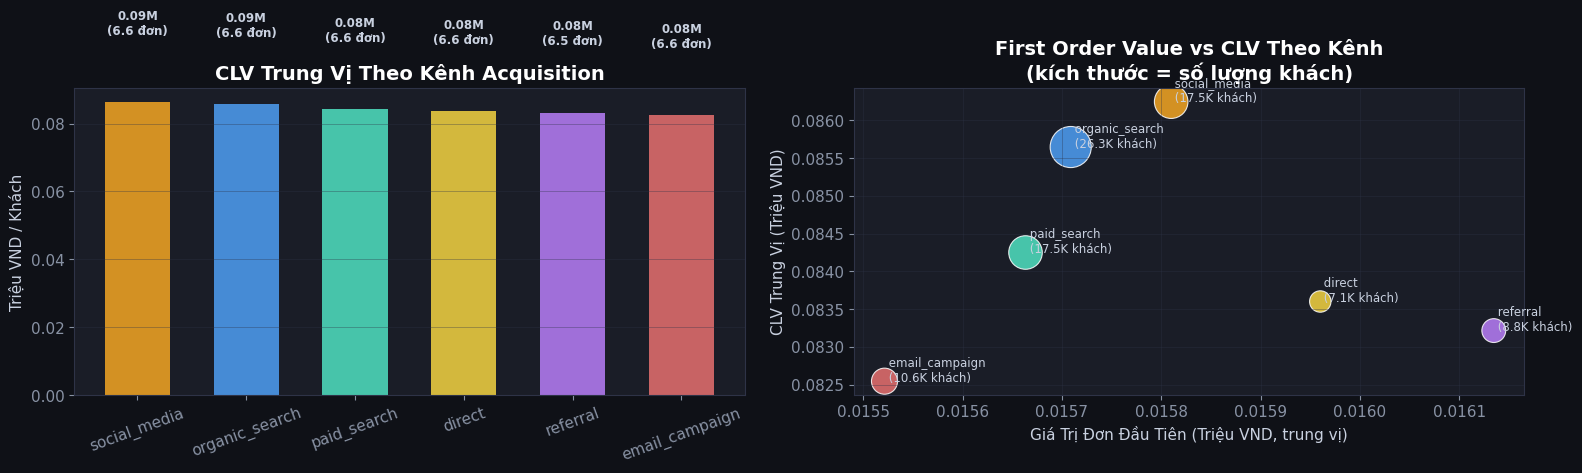

acquisition_channel  n_customers  median_clv_M  avg_orders
       social_media        17516          0.09        6.62
     organic_search        26257          0.09        6.64
        paid_search        17508          0.08        6.60
             direct         7127          0.08        6.55
           referral         8847          0.08        6.54
     email_campaign        10584          0.08        6.59


In [6]:
## 1.4 CLV Theo Kênh Acquisition: Đầu Tư Vào Đâu Hiệu Quả Nhất?

# First order value = revenue của đơn hàng đầu tiên mỗi khách
first_orders = (orders_valid.sort_values('order_date')
                .groupby('customer_id')
                .first()
                .reset_index()[['customer_id','order_id','revenue']]
                .rename(columns={'revenue':'first_order_value'}))

clv_ch = (cust_stats
          .merge(first_orders[['customer_id','first_order_value']], on='customer_id', how='left')
          .dropna(subset=['acquisition_channel'])
          .groupby('acquisition_channel')
          .agg(
              n_customers       = ('customer_id','count'),
              median_clv        = ('total_revenue','median'),
              mean_clv          = ('total_revenue','mean'),
              median_first_val  = ('first_order_value','median'),
              avg_orders        = ('total_orders','mean'),
          )
          .sort_values('median_clv', ascending=False)
          .reset_index())
clv_ch['median_clv_M']       = clv_ch['median_clv'] / 1e6
clv_ch['median_first_val_M'] = clv_ch['median_first_val'] / 1e6

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor('#0f1117')

# ── Left: median CLV by channel ─────────────────────────────────────────
ax = axes[0]
bars = ax.bar(clv_ch['acquisition_channel'], clv_ch['median_clv_M'],
              color=[ch_colors.get(c,'#888') for c in clv_ch['acquisition_channel']],
              alpha=0.85, width=0.6)
for bar, (_, row) in zip(bars, clv_ch.iterrows()):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
            f"{row['median_clv_M']:.2f}M\n({row['avg_orders']:.1f} đơn)",
            ha='center', fontsize=8.5, color='#c9d1e0', fontweight='bold')
ax.set_title('CLV Trung Vị Theo Kênh Acquisition')
ax.set_ylabel('Triệu VND / Khách')
ax.tick_params(axis='x', rotation=20)
ax.grid(axis='y', alpha=0.4)

# ── Right: scatter — first order value vs CLV ────────────────────────────
ax2 = axes[1]
ax2.scatter(
    clv_ch['median_first_val_M'],
    clv_ch['median_clv_M'],
    s=clv_ch['n_customers'] / 30,
    c=[ch_colors.get(c,'#888') for c in clv_ch['acquisition_channel']],
    alpha=0.85, edgecolors='white', linewidths=0.8
)
for _, row in clv_ch.iterrows():
    ax2.annotate(f" {row['acquisition_channel']}\n ({row['n_customers']/1000:.1f}K khách)",
                 (row['median_first_val_M'], row['median_clv_M']),
                 fontsize=8.5, color='#c9d1e0')
ax2.set_xlabel('Giá Trị Đơn Đầu Tiên (Triệu VND, trung vị)')
ax2.set_ylabel('CLV Trung Vị (Triệu VND)')
ax2.set_title('First Order Value vs CLV Theo Kênh\n(kích thước = số lượng khách)')
ax2.grid(alpha=0.4)

plt.tight_layout()
plt.savefig('../outputs/charts/lifecycle/lc_04_clv_channel.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print(clv_ch[['acquisition_channel','n_customers','median_clv_M','avg_orders']].round(2).to_string(index=False))

**Insight 1.4:**
- CLV trung vị gần như bằng nhau trên mọi kênh (~0.09M VND, ~6.6 đơn) → **không có kênh nào vượt trội về chất lượng khách**.
- Hệ quả: quyết định phân bổ ngân sách marketing nên dựa vào **chi phí acquisition per customer** của từng kênh, không phải CLV đầu ra.

### Tổng Hợp Insight Q1

| Phát Hiện | Insight Hành Động |
|-----------|-------------------|
| Acquisition **giảm liên tục từ 2014**, chưa hồi phục | Vấn đề cốt lõi là **acquisition đang chết dần** — retention tốt cũng không bù được nếu không có khách mới |
| CLV và T2P **đồng đều trên mọi kênh** | Chọn kênh dựa vào **chi phí acquisition**, không phải CLV hay tốc độ quay lại |
| **45% khách quay lại sau >1 năm** | Nurturing sequence phải kéo dài 6–12 tháng, không phải 30 ngày |
| Core audience **25–44 tuổi** chiếm 56% | Người đi làm có thu nhập — pricing và product mix phải phù hợp nhóm này |

---

# 2. Retention, CLV & Churn

> *"Sau lần mua đầu, bao nhiêu % khách hàng quay lại? Phân khúc nào có Lifetime Value cao và ai đang có nguy cơ rời bỏ?"*

**4 góc nhìn:**
1. Tỷ lệ repeat purchase & phân bổ số đơn hàng
2. Cohort Retention — % khách quay lại theo quý
3. RFM Segmentation — phân loại khách hàng theo hành vi mua
4. Churn Risk — xác định nhóm cần can thiệp ngay

One-time buyers : 22,716  (25.9%)
Repeat buyers   : 65,123  (74.1%)
Repeat rate     : 74.1%


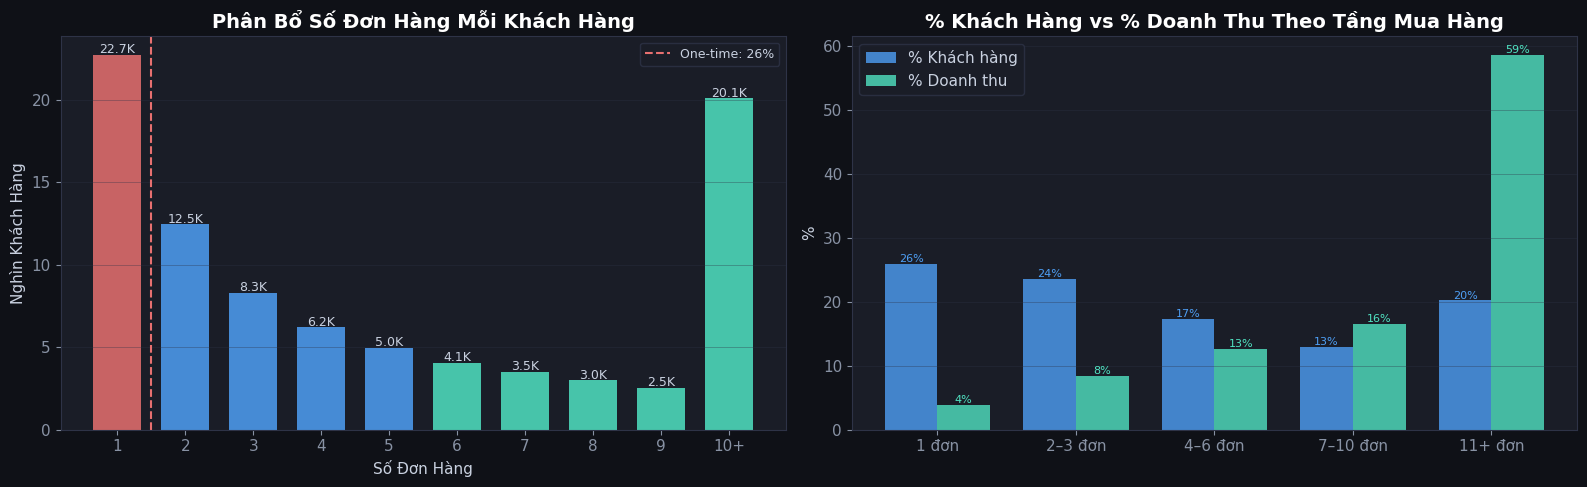

In [7]:
## 2.1 Repeat Purchase: Bao Nhiêu % Khách Quay Lại?

one_time    = (cust_stats['total_orders'] == 1).sum()
repeat      = (cust_stats['total_orders'] >  1).sum()
total_cust  = len(cust_stats)
repeat_rate = repeat / total_cust * 100

print(f"One-time buyers : {one_time:,}  ({one_time/total_cust*100:.1f}%)")
print(f"Repeat buyers   : {repeat:,}  ({repeat/total_cust*100:.1f}%)")
print(f"Repeat rate     : {repeat_rate:.1f}%")

# Order count distribution
order_dist = cust_stats['total_orders'].clip(upper=10).value_counts().sort_index()
order_dist.index = [str(i) if i < 10 else '10+' for i in order_dist.index]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor('#0f1117')

# ── Left: order count distribution ──────────────────────────────────────
ax = axes[0]
colors_od = ['#e87070'] + ['#4e9ff5']*4 + ['#50e3c2']*5
bars = ax.bar(order_dist.index, order_dist.values / 1000,
              color=colors_od[:len(order_dist)], alpha=0.85, width=0.7)
for bar, val in zip(bars, order_dist.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
            f'{val/1000:.1f}K', ha='center', fontsize=9, color='#c9d1e0')
ax.axvline(0.5, color='#e87070', linestyle='--', linewidth=1.5,
           label=f'One-time: {one_time/total_cust*100:.0f}%')
ax.set_title('Phân Bổ Số Đơn Hàng Mỗi Khách Hàng')
ax.set_xlabel('Số Đơn Hàng')
ax.set_ylabel('Nghìn Khách Hàng')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.4)

# ── Right: revenue contribution by order count tier ──────────────────────
ax2 = axes[1]
cust_stats['order_tier'] = pd.cut(cust_stats['total_orders'],
                                   bins=[0,1,3,6,10,9999],
                                   labels=['1 đơn','2–3 đơn','4–6 đơn','7–10 đơn','11+ đơn'])
tier_rev = (cust_stats.groupby('order_tier', observed=True)
            .agg(n=('customer_id','count'), rev=('total_revenue','sum'))
            .assign(rev_pct=lambda d: d['rev']/d['rev'].sum()*100,
                    cust_pct=lambda d: d['n']/d['n'].sum()*100))

x  = np.arange(len(tier_rev))
w  = 0.38
ax2.bar(x - w/2, tier_rev['cust_pct'], w, label='% Khách hàng', color='#4e9ff5', alpha=0.8)
ax2.bar(x + w/2, tier_rev['rev_pct'],  w, label='% Doanh thu',   color='#50e3c2', alpha=0.8)
ax2.set_xticks(x)
ax2.set_xticklabels(tier_rev.index)
ax2.set_title('% Khách Hàng vs % Doanh Thu Theo Tầng Mua Hàng')
ax2.set_ylabel('%')
ax2.legend()
ax2.grid(axis='y', alpha=0.4)
for i, (_, row) in enumerate(tier_rev.iterrows()):
    ax2.text(i - w/2, row['cust_pct']+0.3, f"{row['cust_pct']:.0f}%",
             ha='center', fontsize=8, color='#4e9ff5')
    ax2.text(i + w/2, row['rev_pct']+0.3,  f"{row['rev_pct']:.0f}%",
             ha='center', fontsize=8, color='#50e3c2')

plt.tight_layout()
plt.savefig('../outputs/charts/lifecycle/lc_05_repeat.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

**Insight 2.1:**
- **74.1% khách quay lại mua lần 2** — tỷ lệ retention nền tốt, vấn đề không phải "có quay lại không" mà là "mất bao lâu".
- Nhóm **11+ đơn (20% khách) đóng góp 59% doanh thu** — mất 1 Champions customer tương đương mất ~15 one-time buyers về mặt doanh thu.
- Nhóm 1 đơn (26% khách) chỉ tạo 4% doanh thu → đầu tư giữ chân nhóm này có ROI thấp; ưu tiên chuyển họ sang nhóm 2–3 đơn trước.

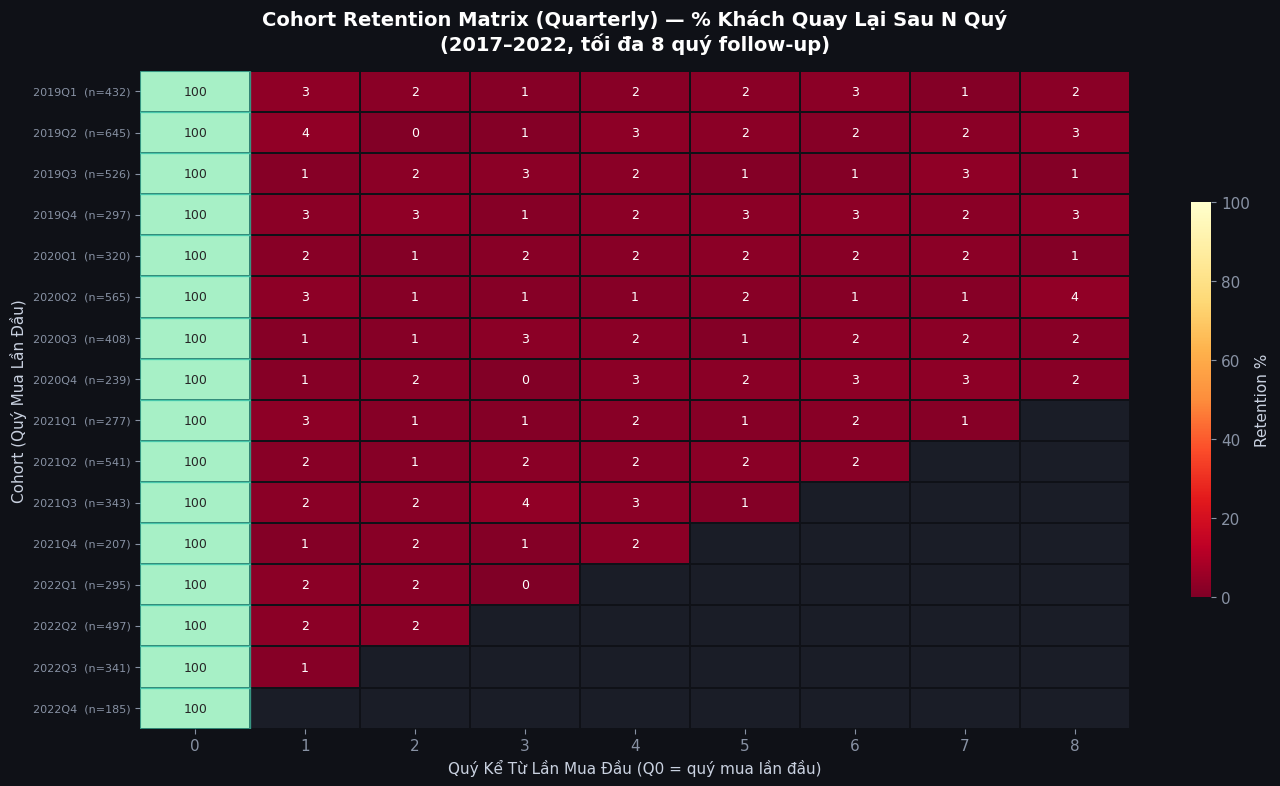

Retention trung bình theo quý:
period_number
0    100.0
1      2.1
2      1.7
3      1.6
4      2.1
5      1.8
6      2.0
7      2.2
8      2.1

Retention Q1 (quý ngay sau lần mua đầu): 2.1%
Retention Q4 (1 năm sau):                2.1%


In [8]:
## 2.2 Cohort Retention Analysis (Quarterly)
# Monthly cohort cho retention ~1.3% vì khách mua trung bình mỗi 10 tháng/lần
# → Quarterly cohort phù hợp hơn với chu kỳ mua hàng thực tế của fashion retail

cohort_df = orders_valid[['customer_id','order_date']].copy()
cohort_df['order_quarter']  = cohort_df['order_date'].dt.to_period('Q')
cohort_df['cohort_quarter'] = (cohort_df.groupby('customer_id')['order_date']
                                .transform('min').dt.to_period('Q'))
cohort_df['period_number']  = (cohort_df['order_quarter'] - cohort_df['cohort_quarter']).apply(lambda x: x.n)

# 2017 trở đi để có đủ follow-up, tối đa 8 quý (2 năm)
cohort_df = cohort_df[cohort_df['cohort_quarter'].dt.year >= 2017]
cohort_df = cohort_df[cohort_df['period_number'] <= 8]

cohort_counts = (cohort_df
                 .groupby(['cohort_quarter','period_number'])['customer_id']
                 .nunique()
                 .reset_index(name='n_customers'))

cohort_pivot = cohort_counts.pivot(index='cohort_quarter', columns='period_number', values='n_customers')
cohort_size  = cohort_pivot[0]
retention    = cohort_pivot.div(cohort_size, axis=0) * 100

retention        = retention.tail(16)
cohort_size_plot = cohort_size.tail(16)

fig, ax = plt.subplots(figsize=(14, 8))
fig.patch.set_facecolor('#0f1117')

mask = retention.isna()
sns.heatmap(
    retention,
    mask=mask,
    annot=True, fmt='.0f',
    cmap='YlOrRd_r',
    vmin=0, vmax=100,
    ax=ax,
    linewidths=0.3, linecolor='#0f1117',
    cbar_kws={'label': 'Retention %', 'shrink': 0.6},
    annot_kws={'size': 9}
)
for i in range(len(retention)):
    ax.add_patch(plt.Rectangle((0, i), 1, 1, fill=True,
                                color='#50e3c2', alpha=0.5, zorder=2))

ax.set_title('Cohort Retention Matrix (Quarterly) — % Khách Quay Lại Sau N Quý\n(2017–2022, tối đa 8 quý follow-up)', pad=15)
ax.set_xlabel('Quý Kể Từ Lần Mua Đầu (Q0 = quý mua lần đầu)')
ax.set_ylabel('Cohort (Quý Mua Lần Đầu)')

cohort_labels = [f"{str(c)}  (n={int(cohort_size_plot[c]):,})"
                 for c in retention.index]
ax.set_yticklabels(cohort_labels, fontsize=8)

plt.tight_layout()
plt.savefig('../outputs/charts/lifecycle/lc_06_cohort.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

avg_ret = retention.mean()
print("Retention trung bình theo quý:")
print(avg_ret.dropna().round(1).to_string())
print(f"\nRetention Q1 (quý ngay sau lần mua đầu): {avg_ret.get(1, float('nan')):.1f}%")
print(f"Retention Q4 (1 năm sau):                {avg_ret.get(4, float('nan')):.1f}%")

**Insight 2.2:**
- Retention mỗi quý dao động **1–4%** và đồng đều qua các năm — không có dấu hiệu cải thiện hoặc xấu đi theo thời gian, không có seasonal peak để khai thác.
- Con số này nhất quán với T2P median 308 ngày: khách không mua theo quý mà theo chu kỳ ~10 tháng, nên trong bất kỳ quý cụ thể nào chỉ một phần nhỏ cohort hoạt động.
- **Hàm ý:** Không nên đo retention bằng tháng hoặc quý — metric phù hợp hơn là "% khách mua lại trong vòng 12 tháng kể từ lần mua đầu".

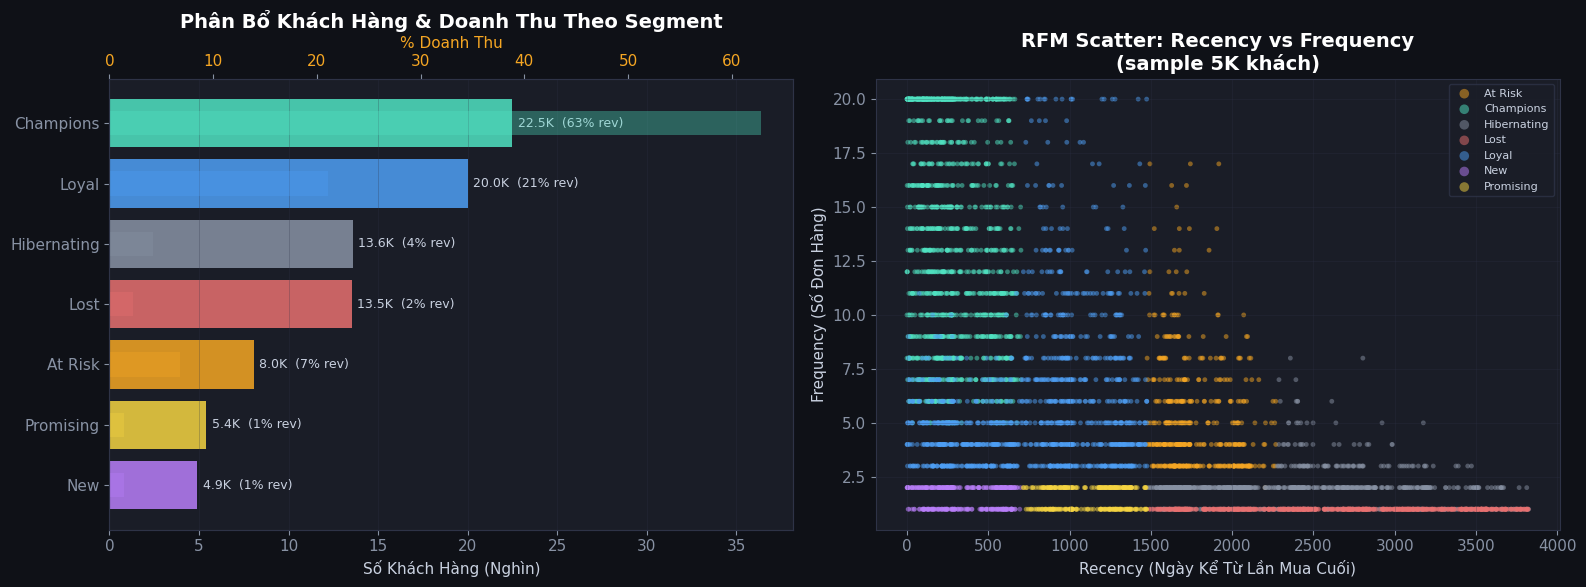

    segment     n  avg_revenue  avg_frequency  avg_recency  rev_share
  Champions 22461     392850.7           15.7        279.3       62.8
      Loyal 19991     148390.1            6.4        781.3       21.1
    At Risk  8048     118375.0            5.2       1793.2        6.8
Hibernating 13569      43595.6            2.0       2450.6        4.2
        New  4873      41563.2            1.5        365.0        1.4
  Promising  5381      37663.5            1.5       1116.6        1.4
       Lost 13516      23105.7            1.0       2649.8        2.2


In [9]:
## 2.3 RFM Segmentation: Phân Loại Khách Hàng Theo Hành Vi

# ── RFM scoring ──────────────────────────────────────────────────────────
rfm = cust_stats[['customer_id','recency_days','total_orders','total_revenue']].copy()
rfm.columns = ['customer_id','recency','frequency','monetary']
rfm = rfm.dropna()

# Quintile scoring (5=best for F,M; 5=best=lowest recency)
rfm['R'] = pd.qcut(rfm['recency'],    5, labels=[5,4,3,2,1]).astype(int)
rfm['F'] = pd.qcut(rfm['frequency'].rank(method='first'), 5, labels=[1,2,3,4,5]).astype(int)
rfm['M'] = pd.qcut(rfm['monetary'].rank(method='first'),  5, labels=[1,2,3,4,5]).astype(int)
rfm['RFM_score'] = rfm['R'] + rfm['F'] + rfm['M']

def rfm_segment(row):
    r, f, m = row['R'], row['F'], row['M']
    if r >= 4 and f >= 4 and m >= 4:   return 'Champions'
    if r >= 3 and f >= 3:               return 'Loyal'
    if r >= 4 and f <= 2:               return 'New'
    if r >= 3 and f <= 2:               return 'Promising'
    if r == 2 and f >= 3:               return 'At Risk'
    if r <= 2 and f >= 2:               return 'Hibernating'
    return 'Lost'

rfm['segment'] = rfm.apply(rfm_segment, axis=1)

seg_stats = (rfm.groupby('segment')
             .agg(n=('customer_id','count'),
                  avg_revenue=('monetary','mean'),
                  avg_frequency=('frequency','mean'),
                  avg_recency=('recency','mean'))
             .assign(rev_share=lambda d: d['n']*d['avg_revenue'] / (rfm['monetary'].sum()) * 100)
             .sort_values('avg_revenue', ascending=False)
             .reset_index())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#0f1117')

# ── Left: treemap-style bar — customers & revenue ────────────────────────
ax = axes[0]
seg_sorted = seg_stats.sort_values('n', ascending=True)
colors_seg = [SEG_COLORS.get(s,'#888') for s in seg_sorted['segment']]
bars = ax.barh(seg_sorted['segment'], seg_sorted['n']/1000, color=colors_seg, alpha=0.85)
ax2_twin = ax.twiny()
ax2_twin.barh(seg_sorted['segment'], seg_sorted['rev_share'],
              color=colors_seg, alpha=0.35, height=0.4)
ax2_twin.set_xlabel('% Doanh Thu', color='#f5a623')
ax2_twin.tick_params(axis='x', labelcolor='#f5a623')
for bar, (_, row) in zip(bars, seg_sorted.iterrows()):
    ax.text(bar.get_width()+0.1, bar.get_y()+bar.get_height()/2,
            f" {row['n']/1000:.1f}K  ({row['rev_share']:.0f}% rev)",
            va='center', fontsize=9, color='#c9d1e0')
ax.set_xlabel('Số Khách Hàng (Nghìn)')
ax.set_title('Phân Bổ Khách Hàng & Doanh Thu Theo Segment')
ax.set_xlim(0, seg_sorted['n'].max()/1000 * 1.7)
ax.grid(axis='x', alpha=0.3)

# ── Right: RFM scatter — Recency vs Frequency, colored by segment ────────
ax3 = axes[1]
sample = rfm.sample(min(5000, len(rfm)), random_state=42)
for seg, grp in sample.groupby('segment'):
    ax3.scatter(grp['recency'], grp['frequency'].clip(upper=20),
                c=SEG_COLORS.get(seg,'#888'), label=seg,
                alpha=0.5, s=12, edgecolors='none')
ax3.set_xlabel('Recency (Ngày Kể Từ Lần Mua Cuối)')
ax3.set_ylabel('Frequency (Số Đơn Hàng)')
ax3.set_title('RFM Scatter: Recency vs Frequency\n(sample 5K khách)')
ax3.legend(fontsize=8, markerscale=2)
ax3.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/charts/lifecycle/lc_07_rfm.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print(seg_stats[['segment','n','avg_revenue','avg_frequency','avg_recency','rev_share']].round(1).to_string(index=False))

**Insight 2.3:**
- **Champions + Loyal = 48% khách hàng nhưng tạo 84% doanh thu** — bảo vệ hai nhóm này là ưu tiên số 1, trước cả việc acquire khách mới.
- Nhóm **At Risk (8K khách, 7% doanh thu)**: từng mua thường xuyên nhưng recency đang xấu đi — đây là nhóm "đang trượt dần", can thiệp còn kịp.
- Nhóm **Hibernating + Lost (27K khách)** tổng cộng chỉ 6% doanh thu dù chiếm 31% số lượng → win-back campaign cho nhóm này có ROI thấp, chỉ nên nhắm vào những khách Hibernating có CLV cao trong quá khứ.

Tổng khách hàng churned (>365d, >=2 đơn): 43,700
Doanh thu đã mất từ nhóm này: 6.4 tỷ VND


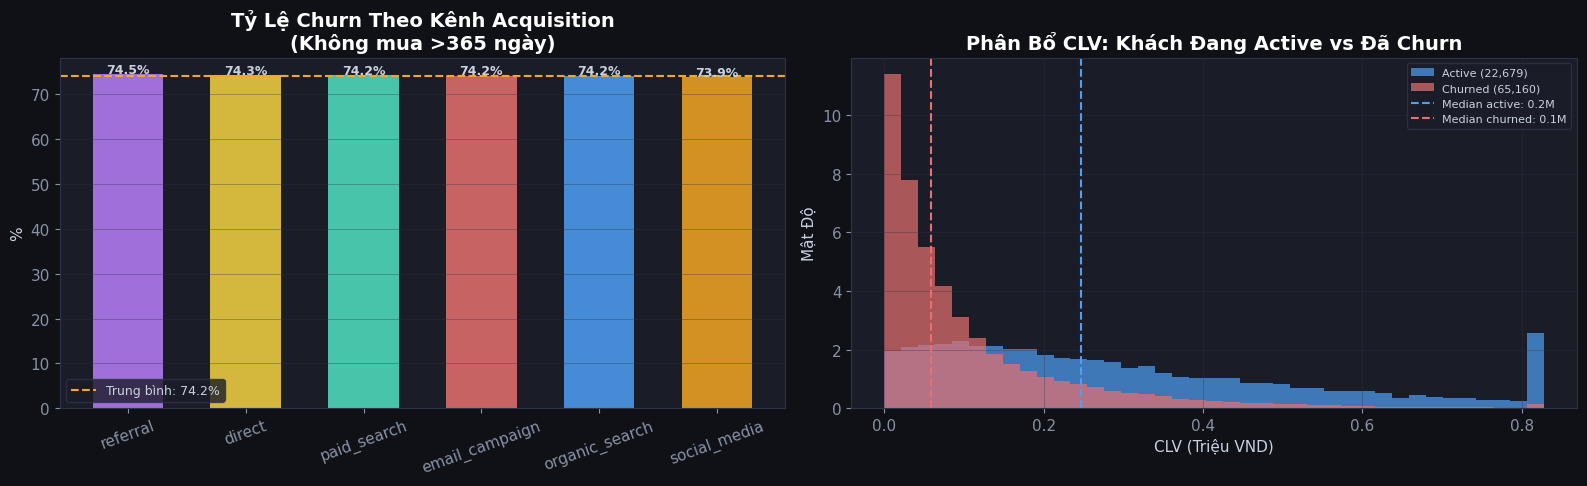

In [10]:
## 2.4 Churn Risk: Ai Cần Được Can Thiệp Ngay?

# Churn threshold: không mua trong >365 ngày (tính đến snapshot 2022-12-31)
CHURN_DAYS = 365
rfm_full = rfm.merge(
    cust_stats[['customer_id','acquisition_channel','age_group','gender']],
    on='customer_id', how='left')

rfm_full['churn_risk'] = rfm_full['recency'] > CHURN_DAYS

# At Risk = mua ít nhất 2 lần nhưng không quay lại > 365 ngày
at_risk = rfm_full[(rfm_full['churn_risk']) & (rfm_full['frequency'] >= 2)].copy()

print(f"Tổng khách hàng churned (>{CHURN_DAYS}d, >=2 đơn): {len(at_risk):,}")
print(f"Doanh thu đã mất từ nhóm này: {at_risk['monetary'].sum()/1e9:.1f} tỷ VND")

# Churn by channel
churn_ch = (rfm_full.groupby('acquisition_channel')
            .agg(total=('customer_id','count'),
                 churned=('churn_risk','sum'))
            .assign(churn_rate=lambda d: d['churned']/d['total']*100)
            .sort_values('churn_rate', ascending=False)
            .reset_index())

# Churn by segment
churn_seg = (rfm_full.groupby('segment')
             .agg(total=('customer_id','count'),
                  churned=('churn_risk','sum'))
             .assign(churn_rate=lambda d: d['churned']/d['total']*100)
             .sort_values('churn_rate', ascending=False)
             .reset_index())

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor('#0f1117')

# ── Left: churn rate by channel ──────────────────────────────────────────
ax = axes[0]
bars = ax.bar(churn_ch['acquisition_channel'], churn_ch['churn_rate'],
              color=[ch_colors.get(c,'#888') for c in churn_ch['acquisition_channel']],
              alpha=0.85, width=0.6)
overall_churn = rfm_full['churn_risk'].mean() * 100
ax.axhline(overall_churn, color='#f5a623', linestyle='--', linewidth=1.5,
           label=f'Trung bình: {overall_churn:.1f}%')
for bar, (_, row) in zip(bars, churn_ch.iterrows()):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            f"{row['churn_rate']:.1f}%", ha='center', fontsize=9,
            color='#c9d1e0', fontweight='bold')
ax.set_title(f'Tỷ Lệ Churn Theo Kênh Acquisition\n(Không mua >{CHURN_DAYS} ngày)')
ax.set_ylabel('%')
ax.tick_params(axis='x', rotation=20)
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.4)

# ── Right: CLV distribution — active vs churned ──────────────────────────
ax2 = axes[1]
active  = rfm_full[~rfm_full['churn_risk']]['monetary'] / 1e6
churned = rfm_full[ rfm_full['churn_risk']]['monetary'] / 1e6
bins_clv = np.linspace(0, active.quantile(0.95), 40)
ax2.hist(active.clip(upper=active.quantile(0.95)),  bins=bins_clv,
         alpha=0.7, color='#4e9ff5', label=f'Active ({len(active):,})', density=True)
ax2.hist(churned.clip(upper=active.quantile(0.95)), bins=bins_clv,
         alpha=0.7, color='#e87070', label=f'Churned ({len(churned):,})', density=True)
ax2.axvline(active.median(),  color='#4e9ff5', linestyle='--', linewidth=1.5,
            label=f'Median active: {active.median():.1f}M')
ax2.axvline(churned.median(), color='#e87070', linestyle='--', linewidth=1.5,
            label=f'Median churned: {churned.median():.1f}M')
ax2.set_title('Phân Bổ CLV: Khách Đang Active vs Đã Churn')
ax2.set_xlabel('CLV (Triệu VND)')
ax2.set_ylabel('Mật Độ')
ax2.legend(fontsize=8)
ax2.grid(alpha=0.4)

plt.tight_layout()
plt.savefig('../outputs/charts/lifecycle/lc_08_churn.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

**Insight 2.4:**
- Tỷ lệ churn **đồng đều ~74.2% trên mọi kênh** → kênh acquisition không ảnh hưởng đến khả năng giữ chân — retention là vấn đề của sản phẩm và trải nghiệm sau mua, không phải của marketing.
- Khách **active có CLV median gấp đôi churned** (0.2M vs 0.1M) — churn xảy ra chủ yếu ở low-value customers; high-value customers có xu hướng trung thành hơn.
- **Hàm ý win-back:** Không nên win-back đồng loạt toàn bộ 43,700 churned — lọc theo CLV lịch sử, chỉ nhắm vào những khách từng có CLV >0.2M (median active) để đảm bảo ROI chiến dịch.

---

# Kết Luận & Khuyến Nghị Chiến Lược

## Trả Lời Hai Câu Hỏi

### Q1 — Acquisition & First Purchase

| Phát Hiện | Hàm Ý Chiến Lược |
|-----------|-------------------|
| **Organic search** là kênh lớn nhất (29.9%), tăng trưởng mạnh đến 2013 rồi suy giảm | Tập trung phục hồi acquisition qua SEO và content marketing |
| Tất cả kênh có CLV và tần suất mua gần như bằng nhau | Tối ưu hóa chi phí acquisition thay vì phân bổ theo CLV kênh |
| Trung vị thời gian quay lại lần 2 là **308 ngày (~10 tháng)** | Thiết kế nurturing dài hạn, không kỳ vọng re-purchase trong 30 ngày |
| Nhóm **25–34 tuổi** chiếm 30% khách hàng | Ưu tiên trải nghiệm và sản phẩm phục vụ nhóm này |

### Q2 — Retention, CLV & Churn

| Phát Hiện | Hàm Ý Chiến Lược |
|-----------|-------------------|
| **74.1% khách quay lại** mua ít nhất lần thứ 2 | Nền tảng retention tốt — vấn đề là tốc độ, không phải tỷ lệ |
| **Champions (25.6% khách) tạo ra 62.8% doanh thu** | Ưu tiên VIP program, early access, exclusive perks cho nhóm này |
| **43,700 khách** có lịch sử mua đã không quay lại >1 năm | Win-back campaign với ưu đãi cá nhân hóa theo lịch sử mua |
| Nhóm At Risk + Hibernating: **21,617 khách** còn tiềm năng phục hồi | Phân tầng can thiệp: email tự động theo recency |

---

## Action Roadmap

```
NGAY LẬP TỨC
├── Post-purchase sequence: email sau lần mua đầu ở tháng 3, 6, 10
└── Win-back campaign cho nhóm At Risk (recency 365–730 ngày)

NGẮN HẠN (1–3 tháng)
├── VIP loyalty program cho Champions & Loyal (top 48% khách, 84% doanh thu)
├── Cross-sell & upsell sau lần mua đầu dựa trên category đã mua
└── Tối ưu chi phí acquisition: cắt kênh kém hiệu quả, scale organic search

TRUNG HẠN (3–6 tháng)
├── Predictive churn model: cảnh báo sớm trước khi khách đạt 6 tháng không mua
└── Personalized recommendation engine theo RFM segment
```

---
*Notebook: Data Storytelling — Customer Lifecycle | Datathon 2026 Round 1*